Lade Daten für das Paradoxon...


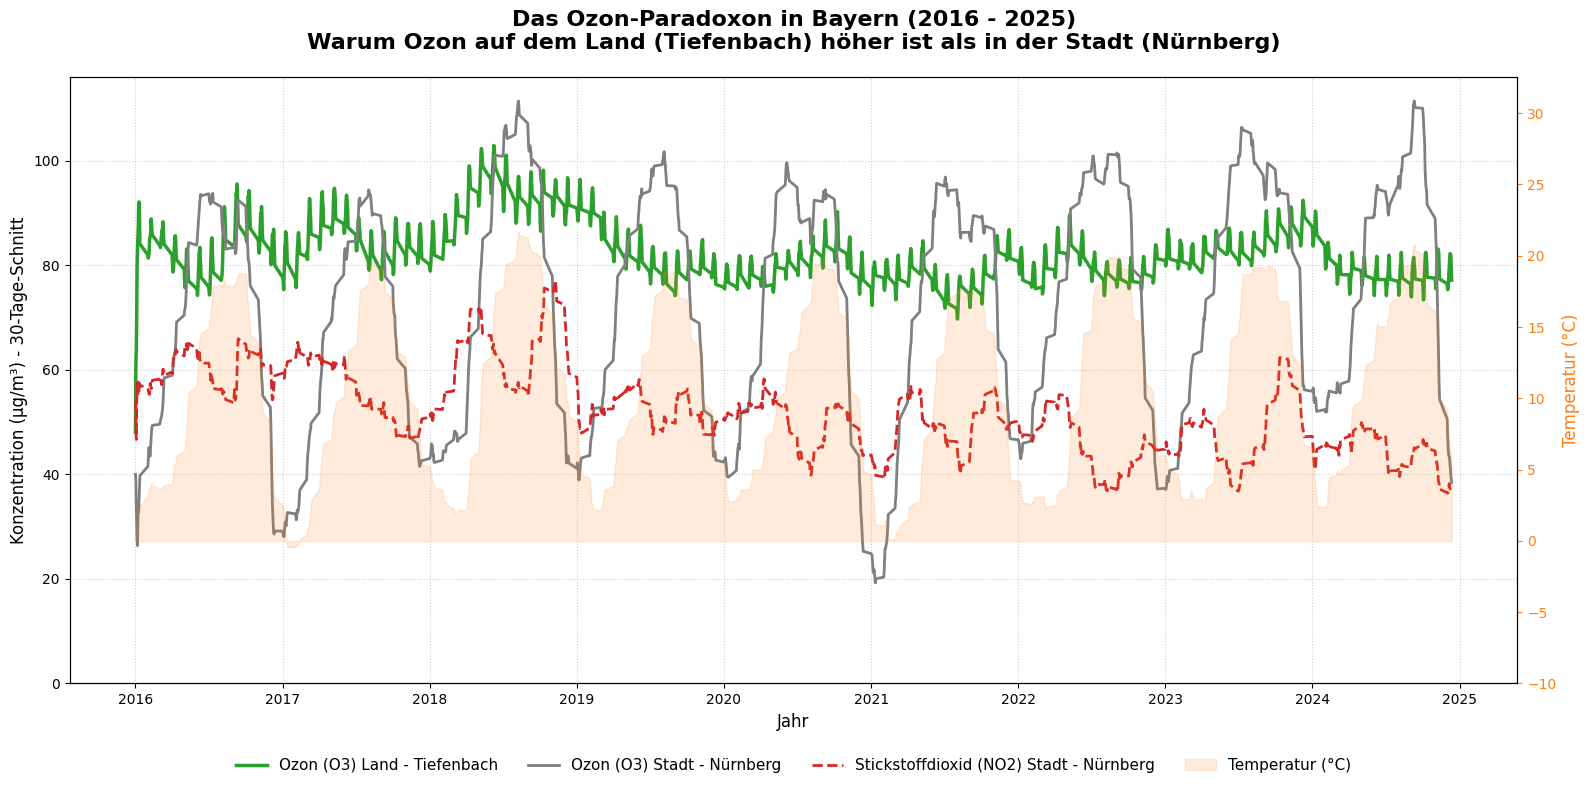

: 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

print("Lade Daten für das Paradoxon...")

# ==========================================
# 1. Tiefenbach-Daten (Land) laden & filtern
# ==========================================
# Bei parquet-Dateien kann man direkt die benötigten Spalten laden, um Speicher zu sparen
df_land = pd.read_parquet("../data/processed/o3_dailymax_2016_2025_station_tiefenbach_bayern.parquet", columns=['datum', 'o3_land'])
df_land['datum'] = pd.to_datetime(df_land['datum'])

# Filter auf den Zielzeitraum
df_land = df_land[(df_land['datum'].dt.year >= 2016) & (df_land['datum'].dt.year <= 2025)]

# ==========================================
# 2. Nürnberg-Daten (Stadt) laden & aufbereiten
# ==========================================
df_stadt = pd.read_csv('../data/raw/data.csv')
df_stadt['datum'] = pd.to_datetime(df_stadt['datum'])
df_stadt = df_stadt[(df_stadt['datum'].dt.year >= 2016) & (df_stadt['datum'].dt.year <= 2025)]

# Tagesmaxima für Schadstoffe, Tagesmittel für Temperatur
df_stadt_daily = df_stadt.groupby('datum').agg({
    'o3': 'max',
    'no2': 'max',
    'temperatur': 'mean' 
}).reset_index()
df_stadt_daily.rename(columns={'o3': 'o3_stadt', 'no2': 'no2_stadt'}, inplace=True)

# ==========================================
# 3. Mergen & Glätten (Rolling Mean)
# ==========================================
# Verknüpfung beider Tabellen über das Datum (Inner Join)
df_merged = pd.merge(df_stadt_daily, df_land, on='datum', how='inner')
df_merged.set_index('datum', inplace=True)

# 30-Tage-Schnitt für eine klare, gut lesbare Kurve ohne zu viel Rauschen
# 30-Tage-gleitender Mittelwert – dämpft tägliches Rauschen für lesbare Trendkurven
df_smoothed = df_merged.rolling(window=30, min_periods=1).mean()

# ==========================================
# 4. Plotting
# ==========================================
fig, ax1 = plt.subplots(figsize=(16, 8))

# --- Schadstoffe (Linke Y-Achse) ---
# Tiefenbach Ozon (Land) - sattes Grün
ax1.plot(df_smoothed.index, df_smoothed['o3_land'], label='Ozon (O3) Land - Tiefenbach', color='#2ca02c', linewidth=2.5)

# Nürnberg Ozon (Stadt) - dunkles Grau
ax1.plot(df_smoothed.index, df_smoothed['o3_stadt'], label='Ozon (O3) Stadt - Nürnberg', color='#7f7f7f', linewidth=2)

# Nürnberg NO2 (Stadt) - Rot, gestrichelt (der Ozon-Killer)
ax1.plot(df_smoothed.index, df_smoothed['no2_stadt'], label='Stickstoffdioxid (NO2) Stadt - Nürnberg', color='#d62728', linestyle='--', linewidth=2)

ax1.set_xlabel('Jahr', fontsize=12)
ax1.set_ylabel('Konzentration (µg/m³) - 30-Tage-Schnitt', fontsize=12)
ax1.tick_params(axis='y')
ax1.set_ylim(bottom=0)

# --- Temperatur (Rechte Y-Achse) ---
ax2 = ax1.twinx()
ax2.fill_between(df_smoothed.index, 0, df_smoothed['temperatur'], color='#ff7f0e', alpha=0.15, label='Temperatur (°C)')
ax2.set_ylabel('Temperatur (°C)', fontsize=12, color='#ff7f0e')
ax2.tick_params(axis='y', colors='#ff7f0e')
# Achse etwas höher ziehen, damit die Farbfläche nicht die Linien überdeckt
ax2.set_ylim(bottom=-10, top=df_smoothed['temperatur'].max() * 1.5)

# --- Layout & Legende ---
plt.title('Das Ozon-Paradoxon in Bayern (2016 - 2025)\nWarum Ozon auf dem Land (Tiefenbach) höher ist als in der Stadt (Nürnberg)', fontsize=16, fontweight='bold', pad=20)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + [lines_2[0]], labels_1 + [labels_2[0]], loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4, frameon=False, fontsize=11)

ax1.grid(True, linestyle=':', alpha=0.6)
fig.tight_layout()

plt.show()